In [7]:
import numpy as np
import seaborn as sns
import pandas as pd
import os
import matplotlib.pyplot as plt

In [8]:
def print_seq_len_histogram(df, n_bins):
    sns.histplot(df["seq_len"])
    print(f"min seq len = {min(df['seq_len'])}")
    print(f"max seq len = {max(df['seq_len'])}")
    plt.show()
    
    freq, bins = np.histogram(df["seq_len"], bins=n_bins)
    n = df.shape[0]
    hist_map = []
    for i in range(n_bins):
        hist_map.append({"start": bins[i], "end":bins[i+1], "count": freq[i], "percentage": freq[i]/n*100})
    hist_df = pd.DataFrame(hist_map)
    print(hist_df)

# Histogram with all filtering and sequence length <= 3036

min seq len = 11
max seq len = 2966


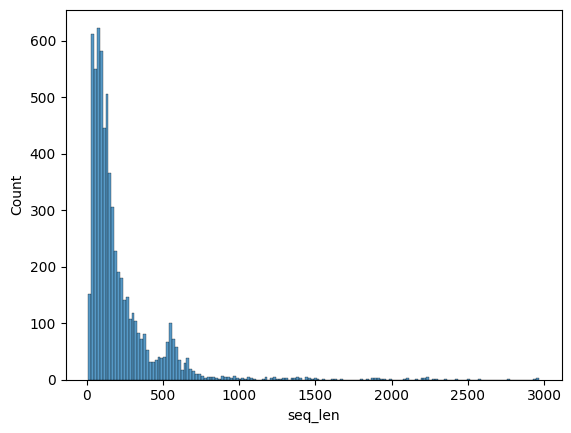

      start      end  count  percentage
0     11.00   257.25   4875   75.441040
1    257.25   503.50    940   14.546580
2    503.50   749.75    504    7.799443
3    749.75   996.00     53    0.820180
4    996.00  1242.25     24    0.371402
5   1242.25  1488.50     25    0.386877
6   1488.50  1734.75      7    0.108326
7   1734.75  1981.00     10    0.154751
8   1981.00  2227.25      9    0.139276
9   2227.25  2473.50      9    0.139276
10  2473.50  2719.75      2    0.030950
11  2719.75  2966.00      4    0.061900


In [9]:
sequence_len = os.path.join(os.getcwd(),"..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_preprocessing_outputs/uniref50_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv_t0.01_c5_seq_len_in_99.9percentile.csv")
df = pd.read_csv(sequence_len)
#This max seq len corresponds to the virus host names with under 3036
df
print_seq_len_histogram(df, 12)

# Prevalence before filtering (IV and NonIV)

In [10]:
beforecutoff = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv.csv")
df = pd.read_csv(beforecutoff)
df
print_seq_len_histogram(df, 12)

FileNotFoundError: [Errno 2] No such file or directory: '/home/sanjanag05/HAVEN/output/uniref50_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv.csv'

# Prevalence before filtering (NonIV only)

In [ ]:
aftercutoff = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv_t0.01_c5.csv")
df2 = pd.read_csv(aftercutoff)
print_seq_len_histogram(df2, 12)

# Chart for sequence lengths before filtering out 1% prevalence & including IV

In [ ]:
def seq_length_analysis(input_file_path, output_file_path):
    df = pd.read_csv(input_file_path)
    df["seq_len"] = df["seq"].apply(lambda x: len(x))
    print(f"min = {df['seq_len'].min()}")
    print(f"max = {df['seq_len'].max()}")
    plt.clf()
    sns.set_theme()
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.histplot(df["seq_len"].values, bins=400, ax=ax, fill=True, alpha=1, kde=False, color=sns.color_palette("dark")[0])
    sns.rugplot(data=df, x="seq_len", height=-.03, clip_on=False, color="black", alpha=.5)
    ax.set_xlabel("Sequence Length", fontsize=12)
    ax.set_ylabel("Number of sequences", fontsize=12)
    ax.set_xticks(np.arange(0, df["seq_len"].max() + 1, 100))
    ax.set_xticklabels(ax.get_xticklabels(), fontsize= 4)
    ax.set_xlim((0, df["seq_len"].max() + 10))
    plt.savefig(output_file_path, bbox_inches="tight", dpi=600)
    plt.show()

In [ ]:
output_pdf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/seqLen.pdf")
seq_length_analysis(beforecutoff, output_pdf)

# Scatter plot for unfiltered sequence lengths

In [ ]:
import matplotlib.colors as color

def scatter(input_file, output_file):
    df = pd.read_csv(input_file)
    df["seq_len"] = df["seq"].apply(lambda x : len(x))
    print(f"min = {df['seq_len'].min()}")
    print(f"max = {df['seq_len'].max()}")

    counts = df["seq_len"].value_counts().sort_index() 
    
    x = counts.index
    y = counts.values

   
    sns.set_theme()
    sns.set_style("whitegrid")
    
    plt.figure(figsize = (9,5))
    plt.scatter(x, y, color = 'darkblue', alpha = 0.7)
    plt.xlabel("Sequence Length", fontsize = 12)
    plt.ylabel("Number of sequences", fontsize = 12)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output_file)
    plt.show()

In [ ]:
output_pdf = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/seqLen.pdf")
scatter(beforecutoff, output_pdf)

# Chart after filtering out IV

In [ ]:
scatter(aftercutoff, output_pdf)

# Chart with prevalence > 2% & sequence length <= 3036

In [ ]:
filtered = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/uniref50_viridae_embl_hosts_pruned_metadata_species_vertebrates_w_seq_non_idv_t0.01_c5_seq_len_in_99.9percentile.csv")
scatter(filtered, output_pdf)

# First and Third charts Density Plot

In [ ]:
def density(input1, input2, output):

    df1 = pd.read_csv(input1)
    df2 = pd.read_csv(input2)
    df1["seq_len"] = df1["seq"].apply(lambda x : len(x))
    df2["seq_len"] = df2["seq"].apply(lambda x : len(x)) 
    
    print(f"min = {df['seq_len'].min()}")
    print(f"max = {df['seq_len'].max()}")

    sns.set_theme()
    sns.set_style("whitegrid")
    plt.figure(figsize = (9,5))

    sns.displot(df1['seq_len'], bins = 100, color = "darkblue", kde= True, alpha = 0.6)
    sns.displot(df2['seq_len'], bins = 100, color = "darkred", kde = True, alpha = 0.6)
    
    plt.xlabel("Sequence Length", fontsize = 12)
    plt.ylabel("Number of sequences", fontsize = 12)
    plt.title("Sequence Lengths Scatter")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output)
    plt.show()
    

In [ ]:
output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/seqDensity.pdf")
density(beforecutoff, filtered, output) 

In [ ]:
def histplot(input1, input2, output):

    df1 = pd.read_csv(input1)
    df2 = pd.read_csv(input2)
    df1["seq_len"] = df1["seq"].apply(lambda x : len(x)) #creates column of sequence lengths
    df2["seq_len"] = df2["seq"].apply(lambda x : len(x)) #creates column of sequence lengths
    
    print(f"min = {df['seq_len'].min()}")
    print(f"max = {df['seq_len'].max()}")

    sns.set_theme()
    sns.set_style("whitegrid")
    plt.figure(figsize = (9,5))
    bin_range = (0, 7200)
    
    sns.histplot(df1['seq_len'].values, bins = 70, color = "darkblue", kde= True, alpha = 0.6, label = "Unfiltered Dataset", binrange=bin_range)
    sns.histplot(df2['seq_len'].values, bins = 70, color = "darkred", kde = True, alpha = 0.6, label = "Filtered Dataset", binrange = bin_range)
    
    plt.xlim(0,7000)
    plt.legend()
    plt.xlabel("Sequence Length", fontsize = 12)
    plt.ylabel("Number of sequences", fontsize = 12)
    plt.title("All Prevalences vs. Filtered")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(output)
    plt.show()
    

In [ ]:
output = os.path.join(os.getcwd(), "..", "..", "..","..", "/home/sanjanag05/HAVEN/output/seqDensity.pdf")
histplot(beforecutoff, filtered, output)

# Findings